In [2]:
import polars as pl
from pygments.styles.dracula import background

INPUT_FILE = "../protbert/datasets/dataset_merged_with_families.parquet"

df = pl.read_parquet(INPUT_FILE).filter(pl.col("reverse") == False)

df

original_seq_full,mutated_seq_full,mut_type,target,reverse,data_source,cath_dominant,cath_all,cath_class,cath_arch,cath_topology,cath_homology
str,str,str,f64,bool,str,str,str,str,str,str,str
"""SAGNQESVVAAVLIPINTALTVGMMTTRVV…","""SAGNQESVVAAVLIPINTALTVGMMTTRVV…","""P68Y""",-0.295097,false,"""megascale""","""G3DSA:3.90.1750.10""","""G3DSA:2.20.70.10;G3DSA:2.60.40…","""G3DSA:3""","""90""","""1750""","""10"""
"""SAGGSAGGKFNKELSVAGREIVTLPNLNDP…","""SAGGSAGGKFNKELSVAGREIVTLPNLNDP…","""D41Y""",-0.018312,false,"""megascale""","""G3DSA:2.30.42.10""","""G3DSA:2.20.70.10;G3DSA:2.30.42…","""G3DSA:2""","""30""","""42""","""10"""
"""SAGKMTGIVKWFNADKGFGFITPDDGSKDV…","""SAGKMTGIVKWFNADKGFGFITPDDGSKDV…","""Q38L""",0.046215,false,"""megascale""","""G3DSA:3.30.170.10""","""G3DSA:3.30.170.10""","""G3DSA:3""","""30""","""170""","""10"""
"""GTTVKVNGTKYKFDTPEEAQKFAKKAADKY…","""GTTVKVNGTKYKFDTPEEAQKFAKKAADKY…","""R42T""",-0.029416,false,"""megascale""","""G3DSA:3.30.890.10""","""G3DSA:3.30.890.10""","""G3DSA:3""","""30""","""890""","""10"""
"""SAGGSAGGSAGGDEIHIHFNGVTIEFRGLT…","""SAGGSAGGSAGGDEIHIHFNGVTIEFRGLT…","""E47K""",-0.023229,false,"""megascale""","""G3DSA:1.20.5.420""","""G3DSA:1.20.5.420""","""G3DSA:1""","""20""","""5""","""420"""
…,…,…,…,…,…,…,…,…,…,…,…
"""MATLNSASTTGTTPSPGHNAPSLPSDTFSS…","""MATLNSASTTGTTPSPGHNAPSLPSDTFSS…","""S1859R""",-0.095211,false,"""lehner""","""G3DSA:2.30.42.10""","""G3DSA:1.10.287.650;G3DSA:2.30.…","""G3DSA:2""","""30""","""42""","""10"""
"""MATLNSASTTGTTPSPGHNAPSLPSDTFSS…","""MATLNSASTTGTTPSPGHNAPSLPSDTFSS…","""T1859R""",-0.367719,false,"""lehner""","""G3DSA:2.30.42.10""","""G3DSA:1.10.287.650;G3DSA:2.30.…","""G3DSA:2""","""30""","""42""","""10"""
"""MATLNSASTTGTTPSPGHNAPSLPSDTFSS…","""MATLNSASTTGTTPSPGHNAPSLPSDTFSS…","""V1859R""",-0.345122,false,"""lehner""","""G3DSA:2.30.42.10""","""G3DSA:1.10.287.650;G3DSA:2.30.…","""G3DSA:2""","""30""","""42""","""10"""


/tmp/ipykernel_39677/3096088406.py:12: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  df_grouped = df2.group_by(pl.col("mut_type")).agg(pl.count()).sort("count", descending=True)


mut_type,count
u32,u32
1,757852
2,106181


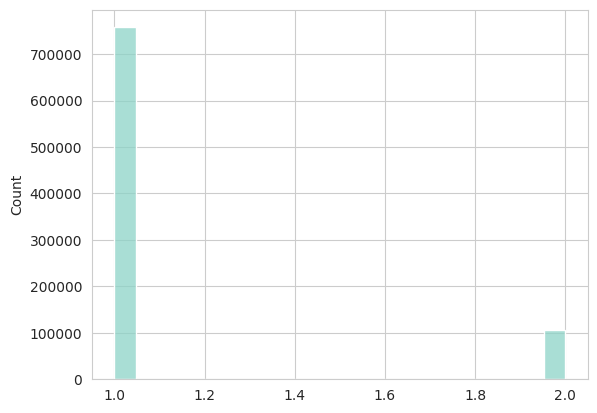

In [12]:
df2 = df.select(pl.col("mut_type").str.count_matches(":")+1)



# histogram
import seaborn as sns
sns.set_style("whitegrid")

sns.histplot(df2.to_numpy().flatten(), kde=False)


df_grouped = df2.group_by(pl.col("mut_type")).agg(pl.count()).sort("count", descending=True)

df_grouped




In [21]:
target.describe()

statistic,target
str,f64
"""count""",864033.0
"""null_count""",0.0
"""mean""",-0.140211
"""std""",0.176915
"""min""",-0.980373
"""25%""",-0.246205
"""50%""",-0.097387
"""75%""",-0.018705
"""max""",0.986593


In [14]:
df.select(pl.col("original_seq_full")).unique()

original_seq_full
str
"""SAGMEQGTVKWFNAEKGSGFIERENGDDVF…"
"""MNNPSETSKPSMESGDGNTGTQTNGLDFQK…"
"""MADDEDYEEVVEYYTEEVVYEEVPGETITK…"
"""LQLFIKTLTGKTFTVEMEPSDTIENLKAKI…"
"""SAGGSPAHPYDRLKTTSTDPVSDIDVTRRE…"
…
"""SAGGSMDETGKELVLALYDYQEKSPREVTM…"
"""GGLTDEELVTMSVRELNQHLRGLSKEEIIQ…"
"""SAGGSAGGSAGGSAGGRLIESLSQMLSMGF…"


In [23]:

import matplotlib.pyplot as plt
import scienceplots

plt.style.use('science')

df.select(pl.col("original_seq_full").str.len_chars()).describe()



statistic,original_seq_full
str,f64
"""count""",864033.0
"""null_count""",0.0
"""mean""",547.629004
"""std""",768.21374
"""min""",44.0
"""25%""",72.0
"""50%""",252.0
"""75%""",744.0
"""max""",8525.0


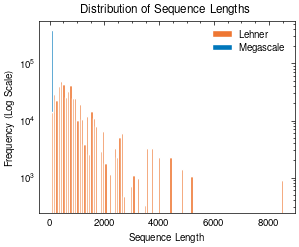

In [32]:
# histogram fitness
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'nature', 'vibrant'])

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "figure.edgecolor": "white"
})


# Příprava dat
data1 = df.filter(pl.col("data_source") == "lehner").select(pl.col("original_seq_full").str.len_chars()).to_series()
data2 = df.filter(pl.col("data_source") == "megascale").select(pl.col("original_seq_full").str.len_chars()).to_series()

# Přidán parametr stacked=True
plt.hist([data1, data2], bins=100, label=['Lehner', "Megascale"], log=True, stacked=True)

plt.title("Distribution of Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency (Log Scale)")
plt.legend(loc='upper right')
plt.savefig("../fig-generation/sequence_length.pdf")
plt.show()

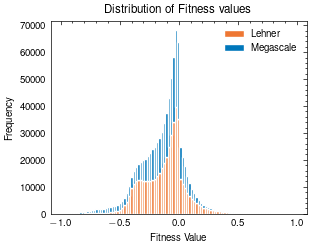

In [34]:
# histogram fitness
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'nature', 'vibrant'])

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "figure.edgecolor": "white"
})

# Příprava dat
data1 = df.filter(pl.col("data_source") == "lehner").select(pl.col("target")).to_series()
data2 = df.filter(pl.col("data_source") == "megascale").select(pl.col("target")).to_series()


plt.hist([data1, data2], bins=100, label=['Lehner', "Megascale"], stacked=True)


plt.title("Distribution of Fitness values")
plt.xlabel("Fitness Value")
plt.ylabel("Frequency")
plt.legend(loc='upper right') # Přidá legendu
plt.savefig("target_distribution.pdf", bbox_inches='tight', transparent=True)
plt.show()